# Tasks Notebook - DICOM Images with Smallest Fixations

## Task 1: For each fixation create a image with a circle around it with dicom image
- Analyze fixation data to find DICOM images with smallest fixations
- Create visualizations with circles around fixations on DICOM images
- Process and display fixation data

## Task 2: System Prompt 
- Set up system prompt for VLM processing
- Configure task descriptions and parameters

## Task 3: Reorder fixations
- Implement fixation reordering functionality
- Sort fixations by duration, size, or other criteria

## Task 4: VLM Process
- Set up Vision Language Model processing pipeline
- Configure image processing and analysis

## Task 5: Pruning wrong fixations prediction
- Implement fixation pruning for wrong predictions
- Filter out incorrect or irrelevant fixations


In [ ]:
SYSTEM_PROMPT = """You are an expert radiologist analyzing gaze fixation patterns on DICOM medical images. Each fixation represents where a radiologist's attention was focused during image interpretation.

Your task is to analyze each fixation frame and provide:
1. A detailed description of what anatomical region or clinical feature the fixation is focused on
2. The frame number/sequence position of this fixation in the overall gaze pattern
3. The clinical relevance and diagnostic importance of this fixation

Base DICOM image: [IMG]

For each fixation frame provided, analyze the gaze pattern and respond in the following format:

Frame {i}: 
- Frame Description: [Detailed description of the anatomical region or clinical feature being examined]
- Frame Number Prediction: [Position in the gaze sequence, e.g., "Frame 3 of 8"]
- Clinical Relevance: [Why this fixation is important for diagnosis]

Analyze the following fixation frame:
"""

In [ ]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
import os

load_dotenv()


llm = ChatOpenAI(
    model="gpt-4o",
    temperature=0,
    max_tokens=None,
    timeout=None,
    max_retries=2,
    api_key=os.getenv("OPENAI_API_KEY")
)

In [ ]:
messages = [
    (
        "system",
        "You are a helpful assistant that translates English to French. Translate the user sentence.",
    ),
    ("human", "I love programming."),
]
ai_msg = llm.invoke(messages)
ai_msg

AIMessage(content="J'adore la programmation.", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 5, 'prompt_tokens': 31, 'total_tokens': 36, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_f64f290af2', 'id': 'chatcmpl-CSa59Sa8fgErtzRVv0x5MPTutKPIq', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--221c3c79-ec26-488c-b5b7-aa546bc7914c-0', usage_metadata={'input_tokens': 31, 'output_tokens': 5, 'total_tokens': 36, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [37]:
import base64

import httpx
from langchain.chat_models import init_chat_model

# Fetch image data
image_url = "https://upload.wikimedia.org/wikipedia/commons/thumb/d/dd/Gfp-wisconsin-madison-the-nature-boardwalk.jpg/2560px-Gfp-wisconsin-madison-the-nature-boardwalk.jpg"
image_data = base64.b64encode(httpx.get(image_url).content).decode("utf-8")


message = {
    "role": "user",
    "content": [
        {
            "type": "text",
            "text": "Describe the weather in this image:",
        },
        {
            "type": "image",
            "source_type": "base64",
            "data": image_data,
            "mime_type": "image/jpeg",
        },
    ],
}
response = llm.invoke([message])
print(response.text())

The weather in the image appears to be clear and sunny. The sky is mostly blue with some scattered clouds, suggesting a pleasant day with good visibility. The lighting indicates it might be either morning or late afternoon.


/home/hiro/miniconda3/envs/gaze/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3699: LangChainDeprecationWarning: Calling .text() as a method is deprecated. Use .text as a property instead (e.g., message.text).
  exec(code_obj, self.user_global_ns, self.user_ns)


=== Loading Fixation Data ===
Loaded fixations: 48959 records
Columns: ['SESSION_ID', 'MEDIA_ID', 'DICOM_ID', 'CNT', 'Time (in secs)', 'TIMETICK(f=10000000)', 'FPOGX', 'FPOGY', 'FPOGS', 'FPOGD', 'FPOGID', 'FPOGV', 'BPOGX', 'BPOGY', 'BPOGV', 'LPCX', 'LPCY', 'LPD', 'LPS', 'LPV', 'RPCX', 'RPCY', 'RPD', 'RPS', 'RPV', 'BKID', 'BKDUR', 'BKPMIN', 'LPMM', 'LPMMV', 'RPMM', 'RPMMV', 'SACCADE_MAG', 'SACCADE_DIR', 'VID_FRAME', 'X_ORIGINAL', 'Y_ORIGINAL']

Sample fixation data:
   SESSION_ID  MEDIA_ID                                      DICOM_ID  CNT  \
0           1         0  1a3f39ce-ebe90275-9a66145a-af03360e-ee3b163b   45   
1           1         0  1a3f39ce-ebe90275-9a66145a-af03360e-ee3b163b   68   
2           1         0  1a3f39ce-ebe90275-9a66145a-af03360e-ee3b163b   86   
3           1         0  1a3f39ce-ebe90275-9a66145a-af03360e-ee3b163b  120   
4           1         0  1a3f39ce-ebe90275-9a66145a-af03360e-ee3b163b  136   

   Time (in secs)  TIMETICK(f=10000000)    FPOGX    FPOGY    

/tmp/ipykernel_10283/1049915366.py:77: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  circle = patches.Circle((x, y), circle_size/2,


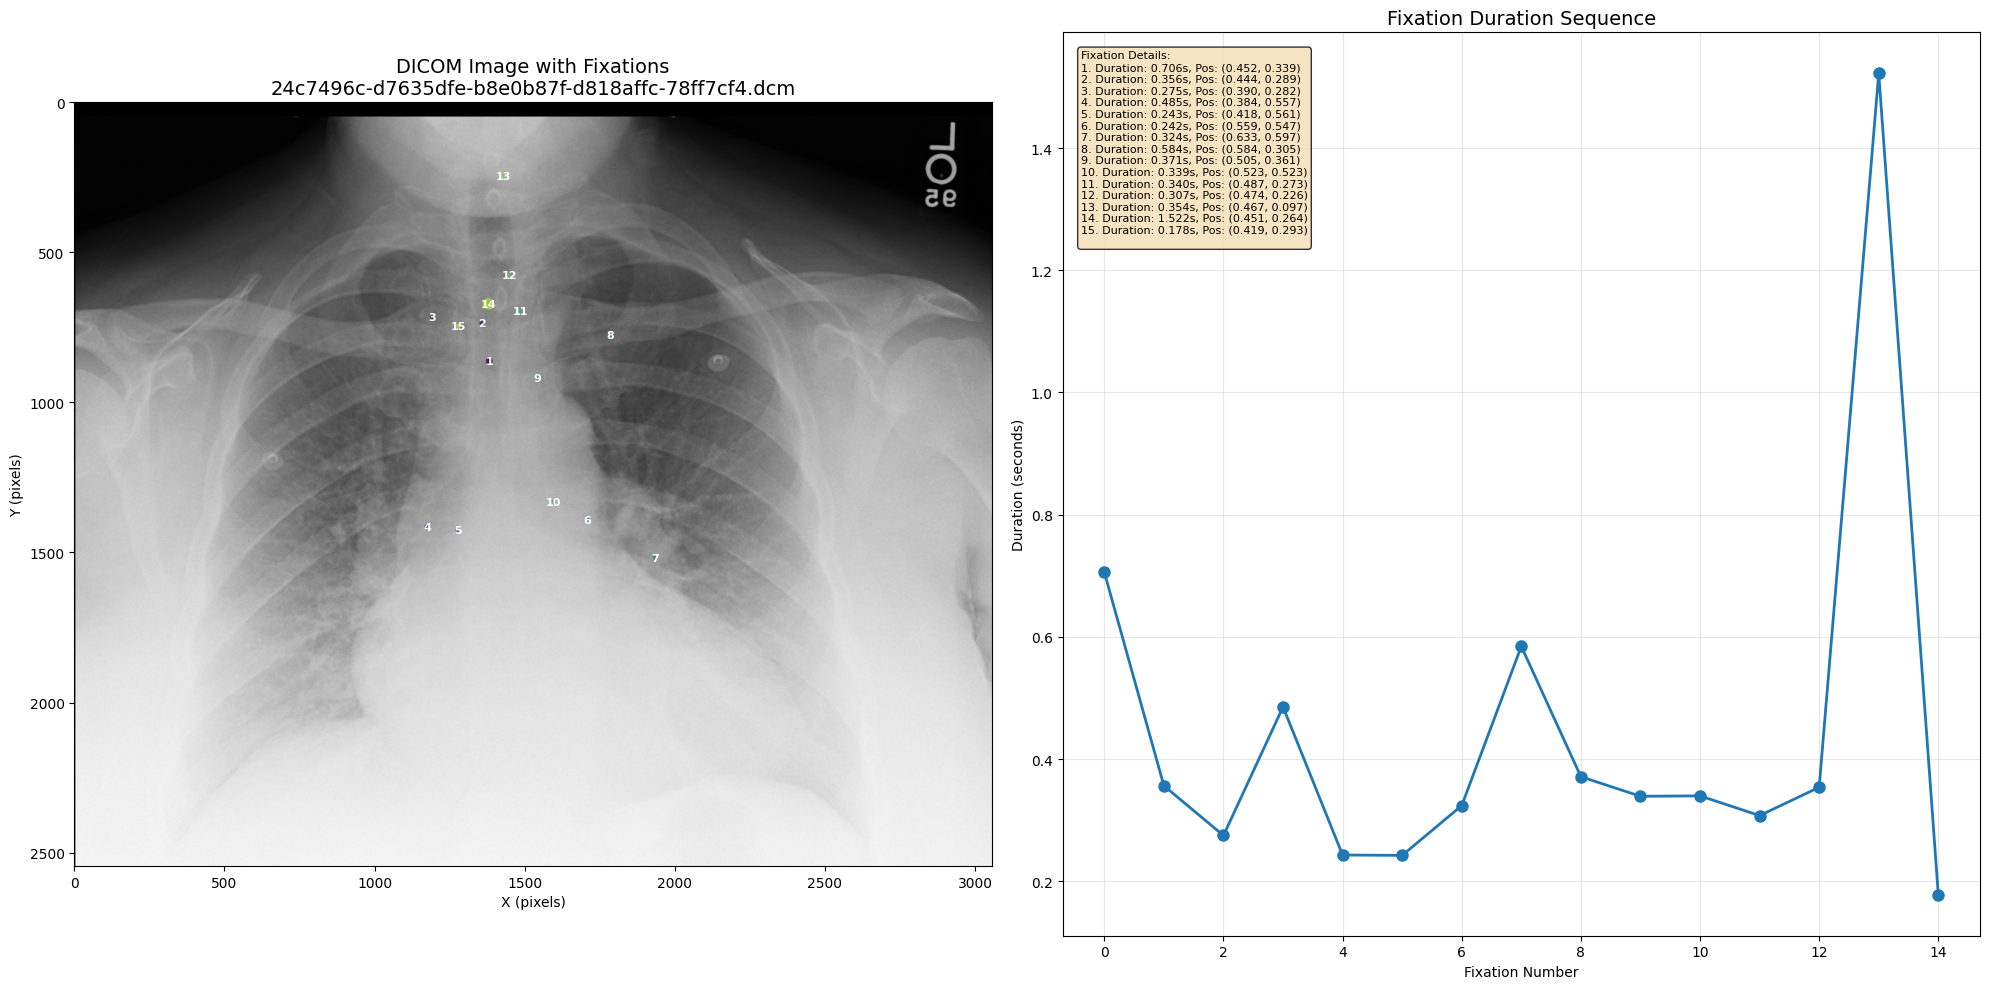


=== Fixation Analysis ===
Total fixations: 15
Total duration: 6.63 seconds
Average duration: 0.442 seconds
Max duration: 1.522 seconds
Min duration: 0.178 seconds


In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
import pydicom

def load_fixation_data():
    """Load fixation data from CSV files"""
    try:
        # Load fixations data
        fixations_path = "/home/hiro/Downloads/Workspace/gz_lab/egd-cxr-1.0.0/1.0.0/fixations.csv"
        fixations_df = pd.read_csv(fixations_path)
        print(f"Loaded fixations: {len(fixations_df)} records")
        print(f"Columns: {list(fixations_df.columns)}")
        return fixations_df
    except Exception as e:
        print(f"Error loading fixation data: {e}")
        return None

def plot_fixations_on_dicom(dicom_path, fixations_df, dicom_id=None, max_fixations=20):
    """
    Plot fixations on DICOM image before converting to base64
    
    Args:
        dicom_path (str): Path to DICOM file
        fixations_df (DataFrame): Fixations data
        dicom_id (str): Specific DICOM ID to filter fixations
        max_fixations (int): Maximum number of fixations to display
    """
    try:
        # Read DICOM file
        dicom_file = pydicom.dcmread(dicom_path)
        image_data = dicom_file.pixel_array
        
        # Get image dimensions
        img_height, img_width = image_data.shape
        
        # Filter fixations for this DICOM ID if provided
        if dicom_id:
            dicom_fixations = fixations_df[fixations_df['DICOM_ID'] == dicom_id].copy()
        else:
            # Get the first DICOM ID from the data
            dicom_fixations = fixations_df[fixations_df['DICOM_ID'] == fixations_df['DICOM_ID'].iloc[0]].copy()
        
        if len(dicom_fixations) == 0:
            print("No fixations found for this DICOM ID")
            return None
        
        # Limit number of fixations
        dicom_fixations = dicom_fixations.head(max_fixations)
        
        # Convert normalized coordinates to pixel coordinates
        # FPOGX and FPOGY are normalized coordinates (0-1)
        dicom_fixations['pixel_x'] = dicom_fixations['FPOGX'] * img_width
        dicom_fixations['pixel_y'] = dicom_fixations['FPOGY'] * img_height
        
        # Create the plot
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
        
        # Plot 1: DICOM image with fixations
        ax1.imshow(image_data, cmap='gray')
        ax1.set_title(f'DICOM Image with Fixations\n{Path(dicom_path).name}', fontsize=14)
        
        # Plot fixations as circles with size based on duration
        for idx, fixation in dicom_fixations.iterrows():
            x, y = fixation['pixel_x'], fixation['pixel_y']
            duration = fixation['FPOGD']  # Fixation duration
            
            # Circle size based on duration (scaled)
            circle_size = max(5, min(50, duration * 20))  # Scale duration to circle size
            
            # Color based on fixation order (rainbow effect)
            color = plt.cm.viridis(idx / len(dicom_fixations))
            
            # Draw fixation circle
            circle = patches.Circle((x, y), circle_size/2, 
                                  color=color, alpha=0.7, 
                                  linewidth=2, edgecolor='white')
            ax1.add_patch(circle)
            
            # Add fixation number
            ax1.text(x, y, str(idx+1), ha='center', va='center', 
                    color='white', fontweight='bold', fontsize=8)
        
        ax1.set_xlim(0, img_width)
        ax1.set_ylim(img_height, 0)  # Flip Y axis for image coordinates
        ax1.set_xlabel('X (pixels)')
        ax1.set_ylabel('Y (pixels)')
        
        # Plot 2: Fixation sequence timeline
        ax2.plot(range(len(dicom_fixations)), dicom_fixations['FPOGD'], 'o-', linewidth=2, markersize=8)
        ax2.set_title('Fixation Duration Sequence', fontsize=14)
        ax2.set_xlabel('Fixation Number')
        ax2.set_ylabel('Duration (seconds)')
        ax2.grid(True, alpha=0.3)
        
        # Add fixation details as text
        fixation_text = "Fixation Details:\n"
        for idx, fixation in dicom_fixations.iterrows():
            fixation_text += f"{idx+1}. Duration: {fixation['FPOGD']:.3f}s, "
            fixation_text += f"Pos: ({fixation['FPOGX']:.3f}, {fixation['FPOGY']:.3f})\n"
        
        ax2.text(0.02, 0.98, fixation_text, transform=ax2.transAxes, 
                verticalalignment='top', fontsize=8, 
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
        
        plt.tight_layout()
        plt.show()
        
        # Print fixation statistics
        print(f"\n=== Fixation Analysis ===")
        print(f"Total fixations: {len(dicom_fixations)}")
        print(f"Total duration: {dicom_fixations['FPOGD'].sum():.2f} seconds")
        print(f"Average duration: {dicom_fixations['FPOGD'].mean():.3f} seconds")
        print(f"Max duration: {dicom_fixations['FPOGD'].max():.3f} seconds")
        print(f"Min duration: {dicom_fixations['FPOGD'].min():.3f} seconds")
        
        return dicom_fixations
        
    except Exception as e:
        print(f"Error plotting fixations: {e}")
        return None

# Load fixation data
print("=== Loading Fixation Data ===")
fixations_df = load_fixation_data()

if fixations_df is not None:
    # Show sample of fixation data
    print(f"\nSample fixation data:")
    print(fixations_df.head())
    
    # Get unique DICOM IDs
    unique_dicom_ids = fixations_df['DICOM_ID'].unique()
    print(f"\nFound {len(unique_dicom_ids)} unique DICOM IDs")
    print(f"First few DICOM IDs: {unique_dicom_ids[:5]}")
    
    # Plot fixations for the first DICOM ID
    sample_dicom_id = unique_dicom_ids[0]
    print(f"\n=== Plotting Fixations for DICOM ID: {sample_dicom_id} ===")
    
    # Use one of the sample DICOM files
    dicom_path = "/home/hiro/Downloads/Workspace/gz_lab/gaze-01/sample/24c7496c-d7635dfe-b8e0b87f-d818affc-78ff7cf4.dcm"
    
    # Plot fixations on DICOM
    fixation_data = plot_fixations_on_dicom(dicom_path, fixations_df, sample_dicom_id, max_fixations=15)
else:
    print("Failed to load fixation data")


In [48]:
def create_fixation_visualization_for_base64(dicom_path, fixations_df, dicom_id, fixation_index=0):
    """
    Create a single fixation visualization that can be converted to base64
    
    Args:
        dicom_path (str): Path to DICOM file
        fixations_df (DataFrame): Fixations data
        dicom_id (str): DICOM ID to filter fixations
        fixation_index (int): Index of the specific fixation to highlight
        
    Returns:
        PIL.Image: Image with fixation visualization
    """
    try:
        # Read DICOM file
        dicom_file = pydicom.dcmread(dicom_path)
        image_data = dicom_file.pixel_array
        
        # Get image dimensions
        img_height, img_width = image_data.shape
        
        # Filter fixations for this DICOM ID
        dicom_fixations = fixations_df[fixations_df['DICOM_ID'] == dicom_id].copy()
        
        if len(dicom_fixations) == 0:
            print("No fixations found for this DICOM ID")
            return None
        
        # Get the specific fixation
        if fixation_index >= len(dicom_fixations):
            fixation_index = 0
        
        target_fixation = dicom_fixations.iloc[fixation_index]
        
        # Convert normalized coordinates to pixel coordinates
        pixel_x = target_fixation['FPOGX'] * img_width
        pixel_y = target_fixation['FPOGY'] * img_height
        
        # Create the visualization
        fig, ax = plt.subplots(1, 1, figsize=(12, 10))
        
        # Display DICOM image
        ax.imshow(image_data, cmap='gray')
        
        # Highlight the target fixation with a large circle
        duration = target_fixation['FPOGD']
        circle_size = max(20, min(100, duration * 30))  # Scale based on duration
        
        # Draw the fixation circle
        circle = patches.Circle((pixel_x, pixel_y), circle_size/2, 
                              color='red', alpha=0.6, 
                              linewidth=4, edgecolor='yellow')
        ax.add_patch(circle)
        
        
        ax.set_xlim(0, img_width)
        ax.set_ylim(img_height, 0)
        ax.set_xlabel('X (pixels)')
        ax.set_ylabel('Y (pixels)')
        
        # Convert plot to PIL Image
        buf = io.BytesIO()
        plt.savefig(buf, format='PNG', dpi=150, bbox_inches='tight')
        buf.seek(0)
        pil_image = Image.open(buf)
        plt.close()
        
        return pil_image
        
    except Exception as e:
        print(f"Error creating fixation visualization: {e}")
        return None

def convert_fixation_visualization_to_base64(dicom_path, fixations_df, dicom_id, fixation_index=0):
    """
    Create fixation visualization and convert to base64
    
    Args:
        dicom_path (str): Path to DICOM file
        fixations_df (DataFrame): Fixations data
        dicom_id (str): DICOM ID to filter fixations
        fixation_index (int): Index of the specific fixation to highlight
        
    Returns:
        str: Base64 encoded image string
    """
    try:
        # Create the visualization
        pil_image = create_fixation_visualization_for_base64(dicom_path, fixations_df, dicom_id, fixation_index)
        
        if pil_image is None:
            return None
        
        # Convert to base64
        img_buffer = io.BytesIO()
        pil_image.save(img_buffer, format='PNG')
        img_bytes = img_buffer.getvalue()
        base64_string = base64.b64encode(img_bytes).decode('utf-8')
        
        return base64_string
        
    except Exception as e:
        print(f"Error converting fixation visualization to base64: {e}")
        return None

# Example: Create fixation visualizations for base64 conversion
if fixations_df is not None:
    print("=== Creating Fixation Visualizations for Base64 ===")
    
    # Get a sample DICOM ID and its fixations
    sample_dicom_id = fixations_df['DICOM_ID'].iloc[0]
    dicom_fixations = fixations_df[fixations_df['DICOM_ID'] == sample_dicom_id]
    
    print(f"Using DICOM ID: {sample_dicom_id}")
    print(f"Found {len(dicom_fixations)} fixations for this DICOM")
    
    # Create visualizations for the first few fixations
    dicom_path = "/home/hiro/Downloads/Workspace/gz_lab/gaze-01/sample/24c7496c-d7635dfe-b8e0b87f-d818affc-78ff7cf4.dcm"
    
    fixation_visualizations = {}
    
    for i in range(min(3, len(dicom_fixations))):  # Create first 3 fixation visualizations
        print(f"\nCreating visualization for fixation {i+1}...")
        
        # Create the visualization
        pil_image = create_fixation_visualization_for_base64(dicom_path, fixations_df, sample_dicom_id, i)
        
        if pil_image:
            # Convert to base64
            base64_string = convert_fixation_visualization_to_base64(dicom_path, fixations_df, sample_dicom_id, i)
            
            if base64_string:
                fixation_visualizations[f'fixation_{i+1}'] = {
                    'base64': base64_string,
                    'length': len(base64_string),
                    'fixation_data': dicom_fixations.iloc[i].to_dict()
                }
                print(f"✓ Created base64 visualization (length: {len(base64_string):,} chars)")
            else:
                print(f"✗ Failed to convert to base64")
        else:
            print(f"✗ Failed to create visualization")
    
    # Display the first visualization
    if fixation_visualizations:
        print(f"\n=== Sample Fixation Visualization ===")
        first_fixation = list(fixation_visualizations.keys())[0]
        fixation_data = fixation_visualizations[first_fixation]['fixation_data']
        
        print(f"Fixation: {first_fixation}")
        print(f"Duration: {fixation_data['FPOGD']:.3f} seconds")
        print(f"Position: ({fixation_data['FPOGX']:.3f}, {fixation_data['FPOGY']:.3f})")
        print(f"Base64 length: {fixation_visualizations[first_fixation]['length']:,} characters")
        
        # Show the first 100 characters of base64
        print(f"Base64 preview: {fixation_visualizations[first_fixation]['base64'][:100]}...")
    
    print(f"\nTotal visualizations created: {len(fixation_visualizations)}")
else:
    print("No fixation data available for visualization")


=== Creating Fixation Visualizations for Base64 ===
Using DICOM ID: 1a3f39ce-ebe90275-9a66145a-af03360e-ee3b163b
Found 34 fixations for this DICOM

Creating visualization for fixation 1...


/tmp/ipykernel_10283/4007774254.py:50: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  circle = patches.Circle((pixel_x, pixel_y), circle_size/2,


✓ Created base64 visualization (length: 1,247,920 chars)

Creating visualization for fixation 2...
✓ Created base64 visualization (length: 1,247,748 chars)

Creating visualization for fixation 3...
✓ Created base64 visualization (length: 1,247,816 chars)

=== Sample Fixation Visualization ===
Fixation: fixation_1
Duration: 0.706 seconds
Position: (0.452, 0.339)
Base64 length: 1,247,920 characters
Base64 preview: iVBORw0KGgoAAAANSUhEUgAABeoAAATnCAYAAACVEkLBAAEAAElEQVR4nOy9S49tyXXfGefezLyPeohFskQVi1K1RFmUTLcIWxDU...

Total visualizations created: 3


In [49]:

message = {
    "role": "user",
    "content": [
        {
            "type": "text",
            "text": SYSTEM_PROMPT,
        },
        {
            "type": "image",
            "source_type": "base64",
            "data": base64_string,
            "mime_type": "image/jpeg",
        },
    ],
}
response = llm.invoke([message])
print(response.text())

I'm unable to analyze specific images directly. However, I can guide you on how to interpret gaze fixation patterns on a chest X-ray.

### Frame Analysis:

**Frame 1:**
- **Frame Description:** The fixation is focused on the left upper lung field, near the clavicle and first rib. This area includes the apex of the lung and part of the mediastinum.
- **Frame Number Prediction:** Frame 1 of X (assuming this is the first fixation in the sequence).
- **Clinical Relevance:** This region is important for identifying apical lung lesions, such as a Pancoast tumor, and assessing for pneumothorax or other abnormalities in the upper lung zone.

### General Tips for Analyzing Gaze Fixations:
1. **Identify Key Anatomical Landmarks:** Recognize structures like the clavicles, ribs, heart borders, and lung fields.
2. **Assess for Common Pathologies:** Look for signs of consolidation, masses, pneumothorax, or pleural effusion.
3. **Sequence of Fixations:** Early fixations often focus on areas of high c